In [1]:
%%time 
%load_ext memory_profiler
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import GPUtil
import os
GPUtil.showUtilization() # GPU utilization
%memit range(10000) #For Ram utilization

2025-11-22 02:30:37.496122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


| ID | GPU | MEM |
------------------
|  0 | 34% |  3% |
peak memory: 567.40 MiB, increment: 0.00 MiB
CPU times: user 6.6 s, sys: 4.55 s, total: 11.1 s
Wall time: 14.5 s


In [2]:
# logs = tf.debugging.set_log_device_placement(True)

In [3]:
print (tf.__version__)

2.20.0


In [5]:
%memit range(10000)
print(tf.config.list_physical_devices('GPU'))


peak memory: 567.00 MiB, increment: 0.00 MiB
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Clear previous TF sessions
tf.keras.backend.clear_session()

In [6]:
# Prevent TensorFlow from grabbing all GPU VRAM at once
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:
# tf.config.set_visible_devices([], 'GPU')
# tf.config.list_physical_devices('GPU')

In [8]:
# Mixed precision for lower VRAM
# mixed_precision.set_global_policy('mixed_float16')

In [2]:
img_size = 256
Batch_size = 32
channels = 3
epoch = 50

In [3]:
%%time
GPUtil.showUtilization()
%memit range(10000)


'''dataset = tf.keras.preprocessing.image_dataset_from_directory("E:/AI-ML course/Potato Disease Detector/archive/PlantVillage",
                                                    shuffle = True,
                                                    image_size = (img_size, img_size),
                                                    batch_size = Batch_size)'''

dataset = tf.keras.preprocessing.image_dataset_from_directory("/mnt/e/AI-ML course/Potato Disease Detector/archive/PlantVillage",
                                                    shuffle = True,
                                                    image_size = (img_size, img_size),
                                                    batch_size = Batch_size)

| ID | GPU | MEM |
------------------
|  0 |  0% |  4% |
peak memory: 566.77 MiB, increment: 0.00 MiB
Found 2152 files belonging to 3 classes.


I0000 00:00:1763712805.372495   10890 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2242 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


CPU times: user 2.61 s, sys: 1.56 s, total: 4.17 s
Wall time: 8.78 s


In [4]:
class_name = dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [11]:
len(dataset)

68

In [5]:
%%time
GPUtil.showUtilization()
%memit range(10000)

for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())
    print()
    print(image_batch[0].shape)

| ID | GPU | MEM |
------------------
|  0 |  0% | 59% |
peak memory: 929.04 MiB, increment: 0.00 MiB
(32, 256, 256, 3)
[0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 0 0 1 1 0 0]

(256, 256, 3)
CPU times: user 258 ms, sys: 483 ms, total: 741 ms
Wall time: 1.11 s


2025-11-21 02:17:25.475658: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
'''plt.figure(figsize=(10,10))
for img_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(dataset.class_names[label_batch[i]])
        plt.axis("off") # this is for x-y axis'''
    

'plt.figure(figsize=(10,10))\nfor img_batch, label_batch in dataset.take(1):\n    for i in range(12):\n        ax = plt.subplot(3,4,i+1)\n        plt.imshow(image_batch[i].numpy().astype("uint8"))\n        plt.title(dataset.class_names[label_batch[i]])\n        plt.axis("off") # this is for x-y axis'

In [5]:
def train_test_val_split(dataset, train_size=0.8, test_size=0.1, shuffle=True, shuffle_size = 10000):
    # remaining will be go into validation dataset
    if shuffle:
        dataset = dataset.shuffle(shuffle_size, seed=12)
    train_ds = dataset.take(int(len(dataset)*train_size))
    val_ds = dataset.skip(int(len(dataset)*train_size))
    test_ds = val_ds.take(int(len(dataset)*test_size))
    val_ds = val_ds.skip(int(len(test_ds)))
    return train_ds, val_ds, test_ds

In [6]:
%%time
GPUtil.showUtilization()
%memit range(10000)

train_ds, val_ds, test_ds = train_test_val_split(dataset)
len(train_ds)

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 929.14 MiB, increment: 0.00 MiB
CPU times: user 280 ms, sys: 113 ms, total: 393 ms
Wall time: 583 ms


54

In [14]:
len(test_ds)

6

In [15]:
len(val_ds)

8

In [7]:
%%time
GPUtil.showUtilization()
%memit range(10000)


train_ds = train_ds.shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 929.14 MiB, increment: 0.00 MiB
CPU times: user 172 ms, sys: 54.7 ms, total: 227 ms
Wall time: 671 ms


In [7]:
# Resizing and rescalling
resizing_and_rescaling = tf.keras.Sequential([layers.Resizing(img_size,img_size),
                                              layers.Rescaling(1.0/255)])

In [8]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([layers.RandomFlip('horizontal_and_vertical'),
                     layers.RandomRotation(0.2)])

In [17]:
# Model Building

In [9]:
input_shape = (Batch_size, img_size, img_size, channels)
n_classes = 3

model = tf.keras.Sequential([
    resizing_and_rescaling,
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(n_classes, activation = 'softmax')
])
model.build(input_shape=input_shape)
    

/home/huzefa_m/miniconda3/envs/bhai/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])

In [11]:
%%time
history = model.fit(
    train_ds,
    epochs = epoch,
    batch_size = Batch_size,
    verbose = 1,
    validation_data = val_ds
)

Epoch 1/50


2025-11-21 03:58:09.810716: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 34 of 10000
2025-11-21 03:58:26.870300: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 03:58:26.872158: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:12: Filling up shuffle buffer (this may take a while): 1 of 1000
2025-11-21 03:58:26.875742: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 03:58:50.225331: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-11-21 04:01:25.796208: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.03GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-21 0

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.4265 - loss: 0.9537

2025-11-21 04:02:46.711644: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 64 of 10000
2025-11-21 04:02:47.210800: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 04:02:47.211289: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 04:02:47.242569: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


54/54 ━━━━━━━━━━━━━━━━━━━━ 295s 844ms/step - accuracy: 0.4676 - loss: 0.9094 - val_accuracy: 0.3750 - val_loss: 0.9310
Epoch 2/50


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.9888 - loss: 0.0297 - val_accuracy: 0.9531 - val_loss: 0.2924
Epoch 49/50


2025-11-21 04:11:24.144214: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.9912 - loss: 0.0252 - val_accuracy: 0.9336 - val_loss: 0.3650
Epoch 50/50


2025-11-21 04:11:33.925331: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.9873 - loss: 0.0332 - val_accuracy: 0.9844 - val_loss: 0.0319
CPU times: user 9min 24s, sys: 5min 23s, total: 14min 48s
Wall time: 13min 47s


## Saving the model and history parameter

In [12]:
%%time
GPUtil.showUtilization()
%memit range(10000)


model.save("potato_disease_model.keras") 
print("Model saved successfully as potato_disease_model.keras")

| ID | GPU | MEM |
------------------
|  0 |  0% | 59% |
peak memory: 3312.52 MiB, increment: 0.00 MiB
Model saved successfully as potato_disease_model.keras
CPU times: user 49 s, sys: 10.7 s, total: 59.7 s
Wall time: 1min


In [13]:
import pickle
import json
import os

# After the model.fit() line

# Define a path for your history dictionary file
history_save_path = './training_history.pkl' # Use .pkl or .pickle

# Open a file in write-binary mode and dump the dictionary
with open(history_save_path, 'wb') as file_pi:
    pickle.dump(history.history, file_pi) # Note: We save history.history, which is the dictionary

print(f"History saved to {history_save_path}")


History saved to ./training_history.pkl


### Cell 1: To train and save the data
!python train_and_save.py

### Cell 2: To evaluate the model 
!python evaluate_model.py


We will need three .ipynb files
1. To train and save the data
2. To evaluate the data
3. To run these two cell commands which we wrote above, this will solve the restart the kernel issue.

## Begin from below to restart the model

In [7]:
%%time
GPUtil.showUtilization()
%memit range(10000)


from tensorflow import keras
loaded_model = keras.models.load_model("potato_disease_model.keras")

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 925.47 MiB, increment: 0.00 MiB
CPU times: user 2.02 s, sys: 0 ns, total: 2.02 s
Wall time: 2.46 s


In [8]:
loaded_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,243 (2.10 MB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 367,496 (1.40 MB)

In [9]:
%%time
GPUtil.showUtilization()
%memit range(10000)


test_scores = loaded_model.evaluate(test_ds)

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 937.96 MiB, increment: 0.00 MiB


2025-11-21 06:22:27.161995: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:7: Filling up shuffle buffer (this may take a while): 40 of 10000
2025-11-21 06:22:34.134734: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 06:22:34.165570: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-11-21 06:22:34.698859: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


6/6 ━━━━━━━━━━━━━━━━━━━━ 271s 5s/step - accuracy: 0.9762 - loss: 0.0740
CPU times: user 1min 14s, sys: 30.1 s, total: 1min 44s
Wall time: 4min 34s


Saving the test_scores

In [10]:
import pickle

save_test = './save_test.pkl'

with open(save_test, 'wb') as file_pi:
    pickle.dump(test_scores, file_pi)

## Opening the model, history and test pickle

In [8]:
%%time
GPUtil.showUtilization()
%memit range(10000)


# Now open the model, history and test_scores


from tensorflow import keras
loaded_model = keras.models.load_model("potato_disease_model.keras")

import pickle

history_save_path = './training_history.pkl'
with open (history_save_path, 'rb') as file_pi:
    loaded_history = pickle.load(file_pi)

save_test_path = './save_test.pkl'
with open (save_test_path, 'rb') as file_pi:
    loaded_save_test = pickle.load(file_pi)

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 929.26 MiB, increment: 0.00 MiB
CPU times: user 2 s, sys: 116 ms, total: 2.11 s
Wall time: 2.54 s


In [8]:
%%time
GPUtil.showUtilization()
%memit range(10000)

loaded_save_test

| ID | GPU | MEM |
------------------
|  0 |  0% | 58% |
peak memory: 938.11 MiB, increment: 0.00 MiB
CPU times: user 204 ms, sys: 0 ns, total: 204 ms
Wall time: 455 ms


[0.07396110892295837, 0.976190447807312]

In [9]:
loaded_history

{'accuracy': [0.46759259700775146,
  0.6508215665817261,
  0.8433098793029785,
  0.9137324094772339,
  0.921875,
  0.9351851940155029,
  0.9600694179534912,
  0.9530516266822815,
  0.9765258431434631,
  0.9419013857841492,
  0.9559859037399292,
  0.9724178314208984,
  0.9788732528686523,
  0.9688966870307922,
  0.9507042169570923,
  0.966549277305603,
  0.9747652411460876,
  0.9700704216957092,
  0.9782863855361938,
  0.9788732528686523,
  0.9853286147117615,
  0.9853286147117615,
  0.98591548204422,
  0.9694835543632507,
  0.9835680723190308,
  0.98591548204422,
  0.9818075299263,
  0.9782863855361938,
  0.9800469279289246,
  0.9759389758110046,
  0.9642018675804138,
  0.9683098793029785,
  0.9812206625938416,
  0.9900234937667847,
  0.9894366264343262,
  0.987089216709137,
  0.9906103014945984,
  0.9907407164573669,
  0.9865023493766785,
  0.9900234937667847,
  0.9884259104728699,
  0.9847418069839478,
  0.9841549396514893,
  0.9906103014945984,
  0.987089216709137,
  0.9724178314208

In [11]:
loaded_history.params

AttributeError: 'dict' object has no attribute 'params'

In [12]:
loaded_history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [13]:
loaded_history['accuracy']

[0.46759259700775146,
 0.6508215665817261,
 0.8433098793029785,
 0.9137324094772339,
 0.921875,
 0.9351851940155029,
 0.9600694179534912,
 0.9530516266822815,
 0.9765258431434631,
 0.9419013857841492,
 0.9559859037399292,
 0.9724178314208984,
 0.9788732528686523,
 0.9688966870307922,
 0.9507042169570923,
 0.966549277305603,
 0.9747652411460876,
 0.9700704216957092,
 0.9782863855361938,
 0.9788732528686523,
 0.9853286147117615,
 0.9853286147117615,
 0.98591548204422,
 0.9694835543632507,
 0.9835680723190308,
 0.98591548204422,
 0.9818075299263,
 0.9782863855361938,
 0.9800469279289246,
 0.9759389758110046,
 0.9642018675804138,
 0.9683098793029785,
 0.9812206625938416,
 0.9900234937667847,
 0.9894366264343262,
 0.987089216709137,
 0.9906103014945984,
 0.9907407164573669,
 0.9865023493766785,
 0.9900234937667847,
 0.9884259104728699,
 0.9847418069839478,
 0.9841549396514893,
 0.9906103014945984,
 0.987089216709137,
 0.9724178314208984,
 0.9935445785522461,
 0.9888497591018677,
 0.99119716

In [9]:
acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']

loss = loaded_history['loss']
val_loss = loaded_history['val_loss']


Text(0.5, 1.0, 'Training and validation Loss')

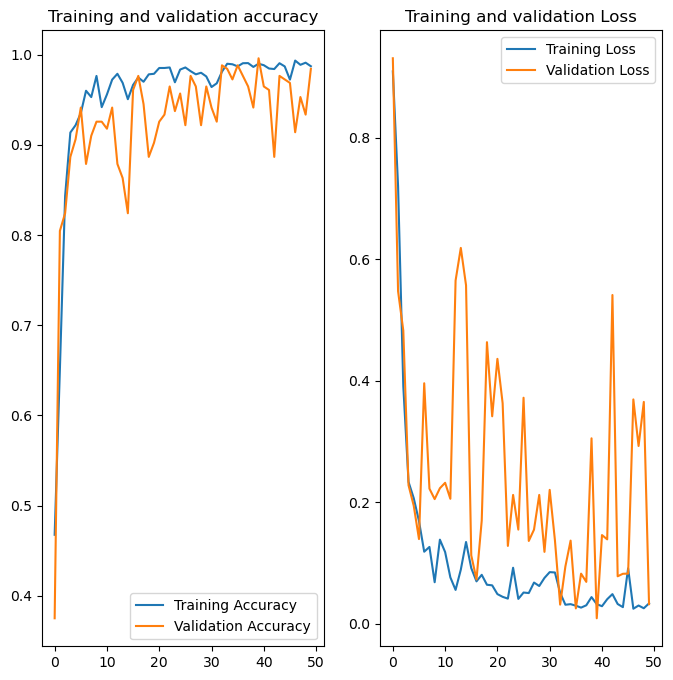

In [10]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epoch), acc, label='Training Accuracy')
plt.plot(range(epoch), val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and validation accuracy')

#loss chart
plt.subplot(1,2,2)
plt.plot(range(epoch), loss, label='Training Loss')
plt.plot(range(epoch), val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and validation Loss')

2025-11-21 08:22:00.347046: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-11-21 08:22:00.347199: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


First image to predict
First image actual label number:  0
First image actual label:  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
predicted label:  Potato___Early_blight


2025-11-21 08:22:02.609151: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


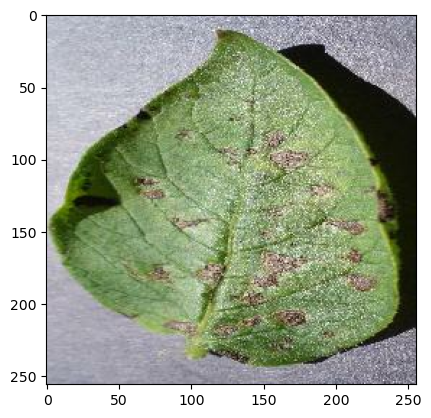

In [11]:
import numpy as np

for image_batch, labels_batch in test_ds.take(1):
    # print(image_batch[0].numpy().astype('uint8'))
    # plt.imshow(image_batch[0].numpy().astype('uint8'))

    first_image = image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print('First image to predict')
    plt.imshow(first_image)
    print('First image actual label number: ', first_label)
    print('First image actual label: ', class_name[first_label])

    batch_prediction = loaded_model.predict(image_batch)
    print('predicted label: ',class_name[np.argmax(batch_prediction[0])])

In [22]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # create a batch

    predictions = model.predict(img_array)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)
    return predicted_class, confidence

2025-11-21 09:40:18.251552: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-11-21 09:40:24.171017: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


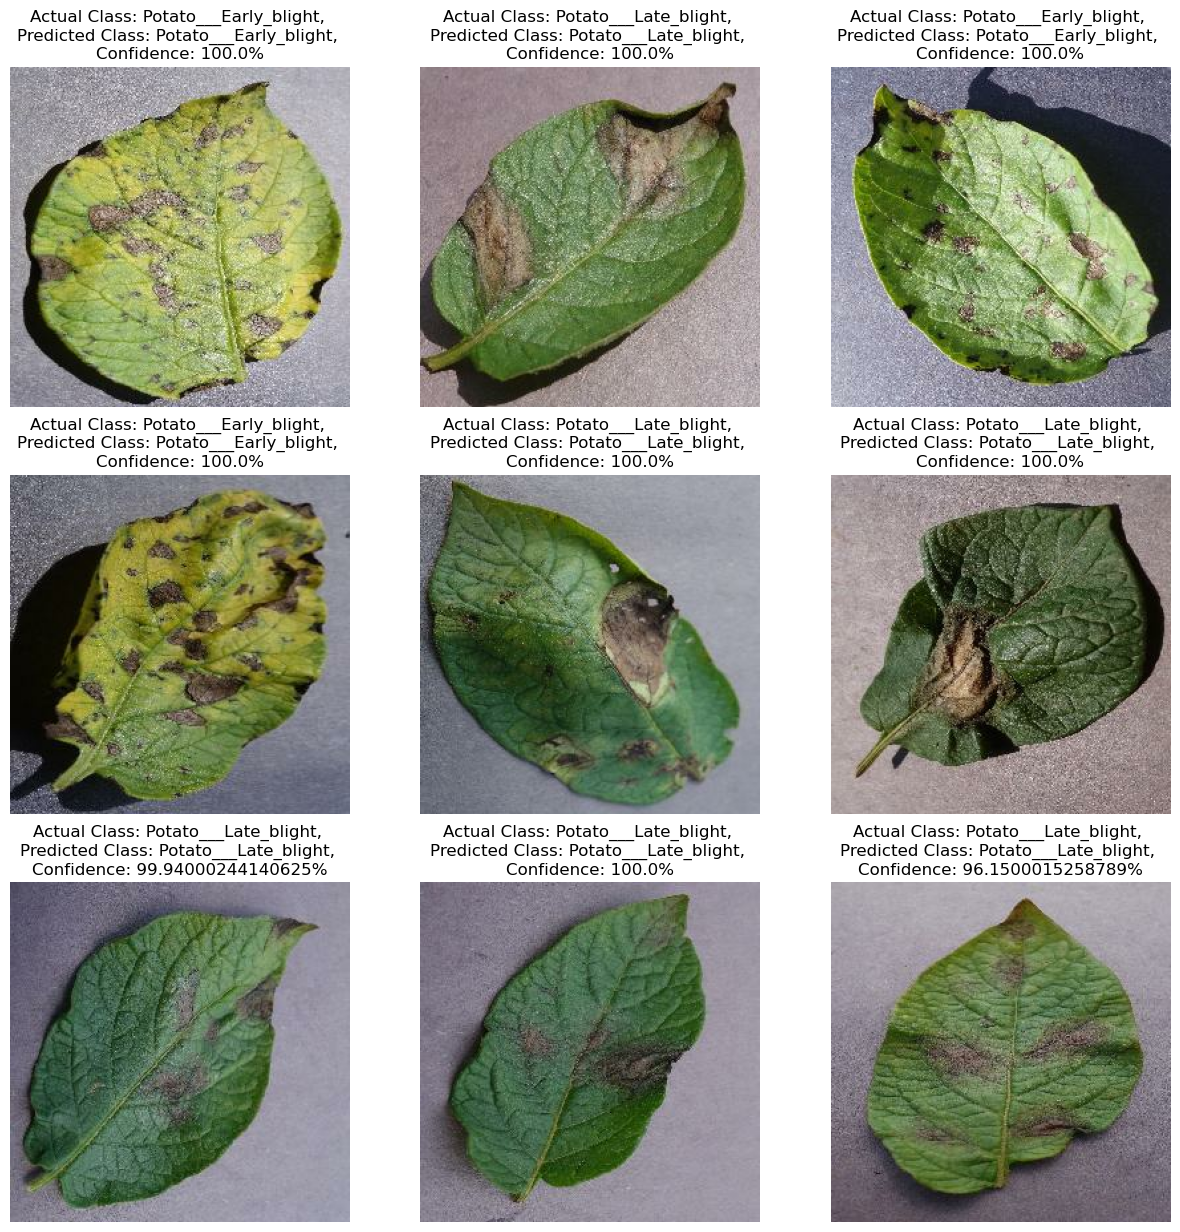

In [23]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range (9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicted_class, confidence = predict(loaded_model, images[i].numpy())
        actual_class = class_name[labels[i]]

        plt.title(f'Actual Class: {actual_class}, \nPredicted Class: {predicted_class}, \nConfidence: {confidence}%')
        plt.axis("off")
    

# FastAPI / tf_serving Backend

In [15]:
%run api/main.py